# Production Planning

## Formulate LP model

#### Parameters of the LP model:
- $D_i$ is the demand (number of units required) for product $i$.
- $C_i$ is the cost (in dollars) for producing each unit of product $i$ *in-house*.
- $P_i$ is the price (in dollars) for purchasing each unit of product $i$.
- $m_i$ is the machining time (in minutes) required to produce each unit of product $i$.
- $a_i$ is the assembly time (in minutes) required to produce each unit of product $i$.
- $f_i$ is the finishing time (in minutes) required to produce each unit of product $i$.
- $T_m$ is the machining time available (in minutes)
- $T_a$ is the assembly time available (in minutes)
- $T_f$ is the finishing time available (in minutes)

#### Decision Variables (all variables non-negative):
- $X_i$ : for $i=1,2,...,5$: number of units of product $i$ produced.
- $Y_i$ : for $i=1,2,...,5$: number of units of product $i$ purchased.

#### Objective function:
- Minimize Cost = $\sum_{i=1}^5 \  (C_i X_i  +  P_i Y_i)$

#### Constraints:
- Demand: $X_i + Y_i \ge D_i$ for $i=1,2,..,5$
- Machining time: $\sum_{i=1}^5 \  m_i X_i  \le  T_m$
- Assembly time: $\sum_{i=1}^5 \  a_i X_i  \le  T_a$
- Finishing time: $\sum_{i=1}^5 \  f_i X_i  \le  T_f$



## Import libraries

We shall use the Python library *PuLP* (https://pypi.org/project/PuLP/) for creating and solving the LP model.

In [7]:
! pip install pulp # install if necessary
from pulp import * # for LP model
import pandas as pd # for data handling

## Get data

We shall extract *CSV* files from the *zip* file with data and read the data we need for this task into *pandas* dataframes:
- ***product***: with data from '*production_planning.product*'.csv'
- ***resource***: with data from '*production_planning.resource.csv*'

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
! unzip '/content/drive/MyDrive/Colab_Notebooks/Datasets/data_production_plan_example.zip'
product = pd.read_csv('production_planning.product.csv') # dataframe with product data
resource = pd.read_csv('production_planning.resource.csv') # dataframe with resource data
! rm *.csv # remove all data files to avoid clutter

Archive:  /content/drive/MyDrive/Colab_Notebooks/Datasets/data_production_plan_example.zip
  inflating: quality_control.new_batches.csv  
  inflating: quality_control.measurements.csv  
  inflating: quality_control.defective.csv  
  inflating: production_planning.resource.csv  
  inflating: production_planning.product.csv  
  inflating: customer_segmentation.unlabeled.csv  
  inflating: customer_segmentation.valid.csv  
  inflating: customer_segmentation.train.csv  


In [10]:
product # display product data

,parameter,P1,P2,P3,P4,P5
0,demand,7000,6000,4000,5000,1000
1,cost_inhouse,93,109,44,80,46
2,cost_outsource,104,123,61,90,59
3,machine_time,2,1,2,2,1
4,assembly_time,1,3,3,1,3
5,finishing_time,3,4,4,2,3


In [11]:
resource # display resource data

,resource,available_hours,hourly_cost
0,machine_time,585,300
1,assembly_time,675,240
2,finishing_time,1110,180


## Get LP parameters
We shall read in parameter values for our LP model from  dataframes.

In [12]:
PRODUCTS = list(product)[1:] # list of products (all but first column header)
N = len(PRODUCTS) # number of products
D, C, P, m, a, f = product.values[:,1:].tolist() # parameter values

RESOURCES = resource.resource.tolist() # list of resources
Tm, Ta, Tf = (60*resource.available_hours).tolist() # parameter values
HOURLY_COST = resource.hourly_cost.tolist()

## Create LP model

In [13]:
LP_file = 'prodution_planning.lp' # name of LP model file
prob = LpProblem(LP_file, LpMinimize) # Create LP model object

### Define decision variables

In [14]:
X = [LpVariable(f'x_{i+1}',0) for i in range(N)] # quantities produced
Y = [LpVariable(f'y_{i+1}',0) for i in range(N)] # quantities purchased

### Specify objective function

In [15]:
prob += lpSum(C[i]*X[i] + P[i]*Y[i] for i in range(N)) # objective function

### Specify demand constraints

In [16]:
for i in range(N):
    prob += X[i] + Y[i] >= D[i] , 'Demand for '+ PRODUCTS[i] # demand for product i

### Add resource availability constraints

In [17]:
for r, t, q in zip(RESOURCES, [m, a, f], [Tm, Ta, Tf]): # for each resource
    prob += sum(t[i]*X[i] for i in range(N)) <= q, r +'_availability' # add resource availability constraint

### Save LP model

In [18]:
prob.writeLP(LP_file) # write model to LP file
print(open(LP_file).read()) # show LP model

\* prodution_planning.lp *\
Minimize
OBJ: 93 x_1 + 109 x_2 + 44 x_3 + 80 x_4 + 46 x_5 + 104 y_1 + 123 y_2 + 61 y_3
 + 90 y_4 + 59 y_5
Subject To
Demand_for_P1: x_1 + y_1 >= 7000
Demand_for_P2: x_2 + y_2 >= 6000
Demand_for_P3: x_3 + y_3 >= 4000
Demand_for_P4: x_4 + y_4 >= 5000
Demand_for_P5: x_5 + y_5 >= 1000
assembly_time_availability: x_1 + 3 x_2 + 3 x_3 + x_4 + 3 x_5 <= 40500
finishing_time_availability: 3 x_1 + 4 x_2 + 4 x_3 + 2 x_4 + 3 x_5 <= 66600
machine_time_availability: 2 x_1 + x_2 + 2 x_3 + 2 x_4 + x_5 <= 35100
End



## Solve LP model

In [19]:
prob.solve() # solve problem
status = LpStatus[prob.status] # optimal found?
print("Solution: ", status)

min_cost = value(prob.objective) # objective function value
print(f'Minimum cost = $ {min_cost:,.2f}') # show optimal cost

Solution:  Optimal
Minimum cost = $ 1,956,120.00


### Optimal decision variable values

In [20]:
# get optimal values for decision variables
X_opt = [x.varValue for x in X] # optimal quantities produced
Y_opt = [y.varValue for y in Y] # optimal quantities purchased

# Save and display optimal quantities in a dataframe
opt_qty = pd.DataFrame([X_opt, Y_opt], columns=PRODUCTS).round(2) # convert to dataframe
opt_qty.insert(0, 'Quantity', ['Produced', 'Purchased']) # add first column
opt_qty.to_csv("optimal_quantities.csv", index=False) # save results
print('Optimal quantities:')
opt_qty # display optimal quantities

Optimal quantities:


,Quantity,P1,P2,P3,P4,P5
0,Produced,6560.0,4980.0,4000.0,4000.0,1000.0
1,Purchased,440.0,1020.0,0.0,1000.0,0.0


### Resources used

In [21]:
resource_use = [] # list with results
for r in RESOURCES: # for each resource
    name = f'{r}_availability' # availability constraint name
    c = prob.constraints[name] # details for constraint
    available = -c.constant # available minutes (RHS of the constraint)
    unused = c.slack # minutes not used
    used = available - unused # minutes used
    resource_use.append([r, used, available, unused]) # append results for resource
# convert results to dataframe
resource_use = pd.DataFrame(resource_use, columns = ['resource', 'used', 'available', 'unused'])
resource_use.to_csv('resource_use.csv', index=False) # sane results
resource_use # show results

,resource,used,available,unused
0,machine_time,35100.0,35100,-0.0
1,assembly_time,40500.0,40500,-0.0
2,finishing_time,66600.0,66600,-0.0


## Sensitivity analysis

In [22]:
max_price = [] # results with maximum cost per additional hour
for r, hc in zip(RESOURCES, HOURLY_COST): # for each resource and its hourly cost
    name = f'{r}_availability' # constraint name
    c = prob.constraints[name] # details for constraint
    shadow_price = -c.pi # cost savings per minute of resource
    savings = 60*shadow_price # cost savings per additional hour of resource
    price = hc + savings # maximum price for an additional hour of resource
    max_price.append([r, hc, savings, price])
# convert results to dataframe
max_price = pd.DataFrame(max_price, columns = ['resource', 'cost per hour', 'savings per hour', 'max price'])
max_price.to_csv('max_price.csv', index=False) # save results
max_price # show results

,resource,cost per hour,savings per hour,max price
0,machine_time,300,168.0,468.0
1,assembly_time,240,144.0,384.0
2,finishing_time,180,60.0,240.0


<Figure size 1200x700 with 0 Axes>

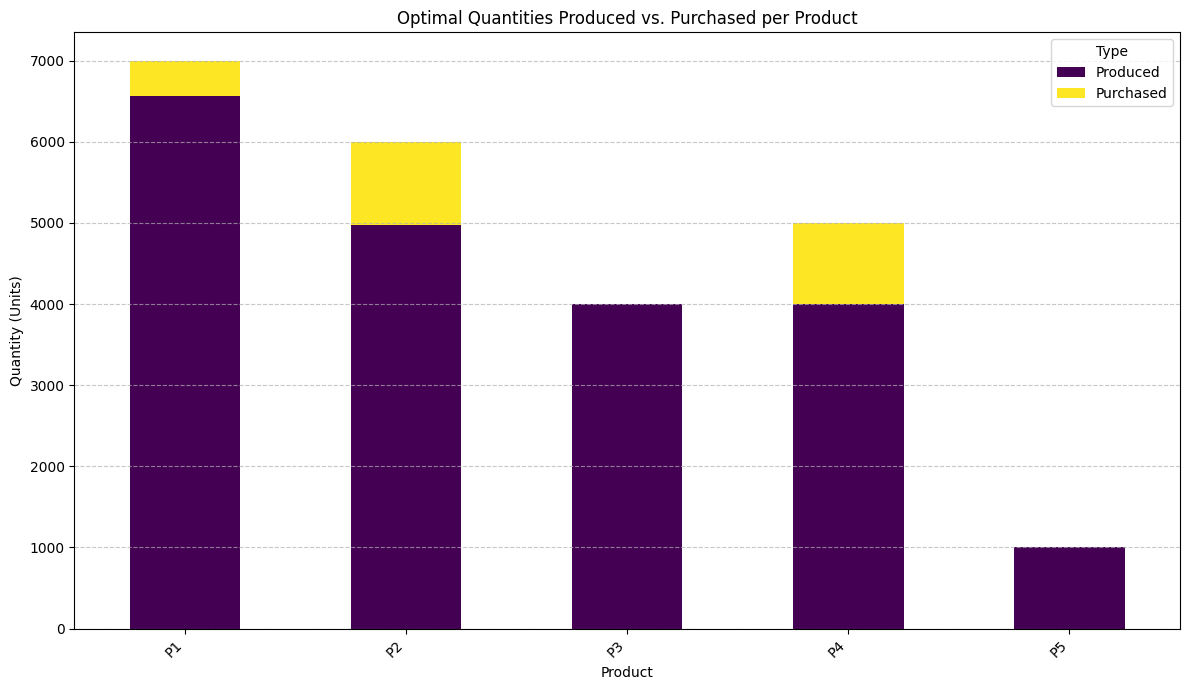

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for stacked bar chart
opt_qty_melted = opt_qty.set_index('Quantity').transpose().reset_index()
opt_qty_melted = opt_qty_melted.rename(columns={'index': 'Product'})

plt.figure(figsize=(12, 7))

# Create a stacked bar plot
opt_qty_melted.plot(x='Product', kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Optimal Quantities Produced vs. Purchased per Product')
plt.xlabel('Product')
plt.ylabel('Quantity (Units)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Resource Utilization

This chart visualizes how much of each resource (machine, assembly, and finishing time) was used, available, and unused in the optimal solution. This helps identify bottlenecks (resources fully used) and underutilized resources.

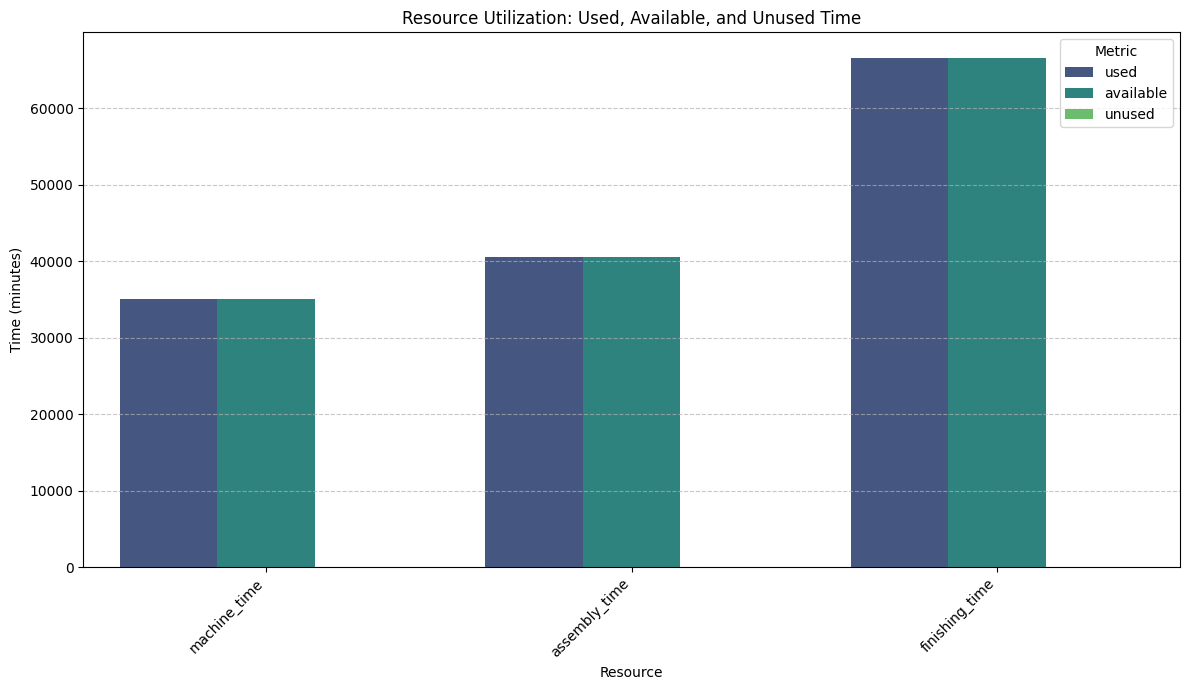

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for resource utilization plot
resource_use_melted = resource_use.melt(id_vars='resource', var_name='Metric', value_vars=['used', 'available', 'unused'])

plt.figure(figsize=(12, 7))
sns.barplot(x='resource', y='value', hue='Metric', data=resource_use_melted, palette='viridis')

plt.title('Resource Utilization: Used, Available, and Unused Time')
plt.xlabel('Resource')
plt.ylabel('Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Maximum Price for Additional Resource Hours

This chart visualizes the maximum price (original hourly cost + potential savings) you should be willing to pay for an additional hour of each resource. This is derived from the sensitivity analysis (shadow prices) and indicates the value of increasing capacity for each resource.

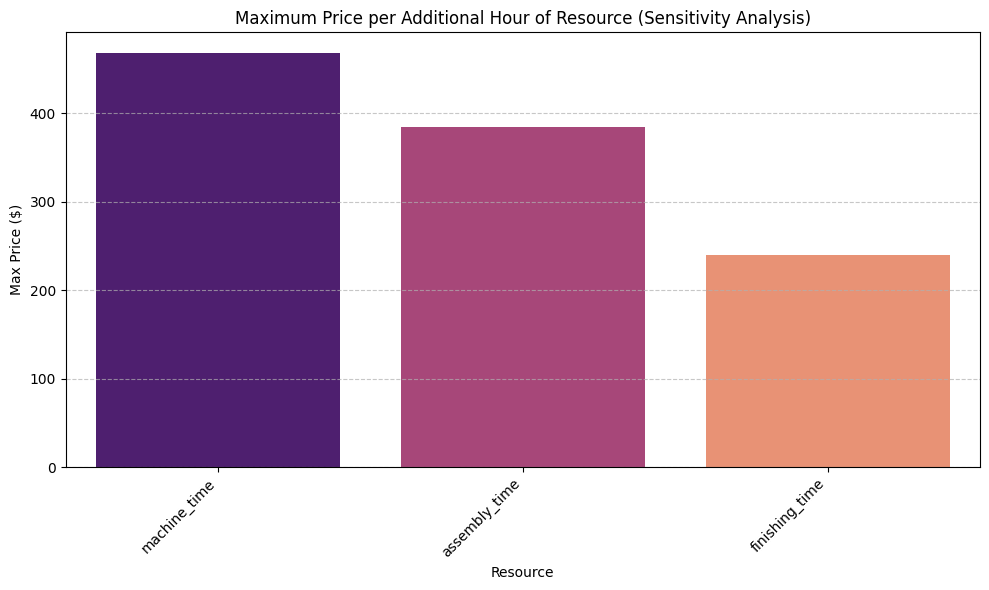

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='resource', y='max price', data=max_price, palette='magma', hue='resource', legend=False)
plt.title('Maximum Price per Additional Hour of Resource (Sensitivity Analysis)')
plt.xlabel('Resource')
plt.ylabel('Max Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()